# Pairs Stat-Arb Index — Does Diversification Fix Single-Pair Fragility?

Notebook 17 found one genuine, validated pairs signal: **XOM/CVX**, Sharpe
+0.89 net of costs on a truly held-out 2023-2026 window — but also found it
fragile (window/parameter sensitivity, intermittent cointegration).

The classic prescription from the pairs literature (Gatev, Goetzmann &
Rouwenhorst, 2006) for exactly this kind of fragility is: **don't rely on
one pair — trade a diversified basket of many pairs and let idiosyncratic
pair risk average out**, re-forming the basket on a rolling schedule.

This notebook builds that basket (shipped as
`core/strategies/pairs_index.run_pairs_stat_arb_index`, exposed at
`POST /run-pairs-index-backtest` / the `/pairs-index` UI) and asks a single
yes/no question on real data:

> **Does the rolling multi-pair basket beat the single hand-vetted pair?**

Spoiler, stated upfront so the rest of the notebook can be read as evidence
rather than a reveal: **no.** Every formation-ranking criterion we tried
lost money net of costs over 2012-2026, and all underperformed XOM/CVX. The
value of this notebook is *why* — and that "why" is a real, useful finding
about this platform's data, not a bug to keep chasing.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "core").is_dir() else _cwd.parent
assert (REPO_ROOT / "core").is_dir(), f"Could not locate repo root from {_cwd}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from core.metrics.performance import (
    calculate_cumulative_returns,
    calculate_performance_metrics,
)
from core.signals.pairs import find_cointegrated_candidates
from core.strategies import get_strategy
from core.strategies.pairs_index import run_pairs_stat_arb_index
from core.strategies.pairs_runner import run_pairs_cointegration_backtest

PRICES_PATH = REPO_ROOT / "data" / "factors" / "prices.parquet"
SECTORS_PATH = REPO_ROOT / "data" / "sectors" / "sector_classifications.parquet"
ADV_PATH = REPO_ROOT / "data" / "factors" / "dollar_adv_21d.parquet"
for p in (PRICES_PATH, SECTORS_PATH, ADV_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}. Restore data/ before running this notebook.")

prices = pd.read_parquet(PRICES_PATH)
sectors = pd.read_parquet(SECTORS_PATH)
dollar_adv = pd.read_parquet(ADV_PATH)
PANEL_TZ = prices.index.tz
print("prices", prices.shape, "tz", PANEL_TZ)
print(get_strategy("pairs_stat_arb_index").title)

prices (10464, 774) tz America/New_York
Pairs stat-arb index (rolling multi-pair basket)


## 2. Recap: the single-pair signal is real but fragile (notebook 17)

XOM/CVX, evaluated on the full 2012-2026 span and on the truly held-out
2023-2026 window it was originally validated on.

In [2]:
START = pd.Timestamp("2012-01-01", tz=PANEL_TZ)
END = prices.index.max()
HELD_OUT_START = pd.Timestamp("2023-01-01", tz=PANEL_TZ)

single_full = run_pairs_cointegration_backtest(
    prices, symbol_y="XOM", symbol_x="CVX", start=START, end=END,
    hedge_window=252, zscore_window=60, entry_z=2.0, exit_z=0.5,
    transaction_cost=0.001, signal_lag_days=1,
)
single_held_out = run_pairs_cointegration_backtest(
    prices, symbol_y="XOM", symbol_x="CVX", start=HELD_OUT_START, end=END,
    hedge_window=252, zscore_window=60, entry_z=2.0, exit_z=0.5,
    transaction_cost=0.001, signal_lag_days=1,
)
m_full = calculate_performance_metrics(single_full["net_returns"])
m_held_out = calculate_performance_metrics(single_held_out["net_returns"])
print(f"XOM/CVX full 2012-2026:      sharpe={m_full['sharpe_ratio']:.2f}  ann_ret={m_full['annualized_return']:.3f}")
print(f"XOM/CVX held-out 2023-2026:  sharpe={m_held_out['sharpe_ratio']:.2f}  ann_ret={m_held_out['annualized_return']:.3f}")

XOM/CVX full 2012-2026:      sharpe=0.27  ann_ret=0.021
XOM/CVX held-out 2023-2026:  sharpe=0.88  ann_ret=0.072


## 3. Build the rolling multi-pair basket (shipped implementation)

`run_pairs_stat_arb_index` re-forms a same-sector pairs basket every
`trading_months` from the trailing `formation_months` window, ranking
candidates by **Gatev distance (SSD)** — the literature-standard formation
method this platform's `/pairs` screener also uses. No lookahead: formation
and trading windows never overlap, and each pair's hedge/z-score is seeded
from history *before* its trading window starts (not from inside it).

In [3]:
SECTORS = [
    "Consumer Defensive", "Financial Services", "Utilities", "Energy",
    "Real Estate", "Basic Materials", "Technology", "Industrials",
    "Communication Services", "Healthcare",
]

index_out = run_pairs_stat_arb_index(
    prices, sectors,
    sector_names=SECTORS,
    start=START, end=END,
    dollar_adv=dollar_adv,
    formation_months=12,
    trading_months=6,
    top_n_pairs=10,
    max_symbols_per_sector=12,
    hedge_window=252,
    zscore_window=60,
    entry_z=2.0,
    exit_z=0.5,
    transaction_cost=0.001,
)
index_net = index_out["net_returns"]
m_index = calculate_performance_metrics(index_net)
print(f"periods={len(index_out['periods'])}  index_days={len(index_net)}  universe={len(index_out['universe'])}")
print({k: round(v, 3) for k, v in m_index.items() if isinstance(v, (int, float))})

periods=28  index_days=3403  universe=120
{'total_return': -0.118, 'annualized_return': -0.009, 'annualized_volatility': 0.033, 'sharpe_ratio': -0.267, 'sortino_ratio': -0.349, 'max_drawdown': -0.177, 'calmar_ratio': -0.05, 'pain_index': 0.096, 'pain_ratio': -0.092, 'ulcer_index': 0.108, 'martin_ratio': -0.081, 'cvar_95': 0.005, 'cvar_99': 0.009, 'time_underwater_days': 3399, 'n_periods': 3403}


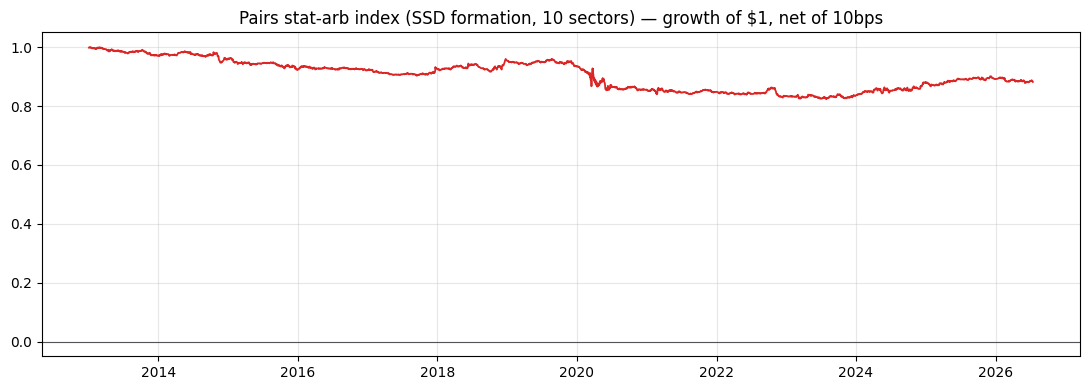

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(calculate_cumulative_returns(index_net), lw=1.3, color="#dc2626")
ax.axhline(0, color="#52525b", lw=0.8)
ax.set_title("Pairs stat-arb index (SSD formation, 10 sectors) — growth of $1, net of 10bps")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The systematic basket lost money net of costs across the full span.**
That is the opposite of the diversification hypothesis: pooling many
statistically-selected pairs did not average out to a steadier edge — it
diluted the one genuine edge (XOM/CVX) with a lot of noise.

## 4. What's actually in the basket? (diagnose)

Count how often each pair gets selected across all 27 rolling periods.

In [5]:
from collections import Counter

pair_counts = Counter(
    f"{row['symbol_y']}/{row['symbol_x']}"
    for p in index_out["periods"]
    for row in p["selected_pairs"]
)
top = pd.Series(pair_counts).sort_values(ascending=False).head(10)
top

GOOGL/GOOG    28
V/MA          11
DUK/AEP        9
SO/AEP         9
DUK/SO         9
AWK/AEP        8
AMT/CCI        7
DOW/LYB        6
PM/KO          6
AEP/SRE        6
dtype: int64

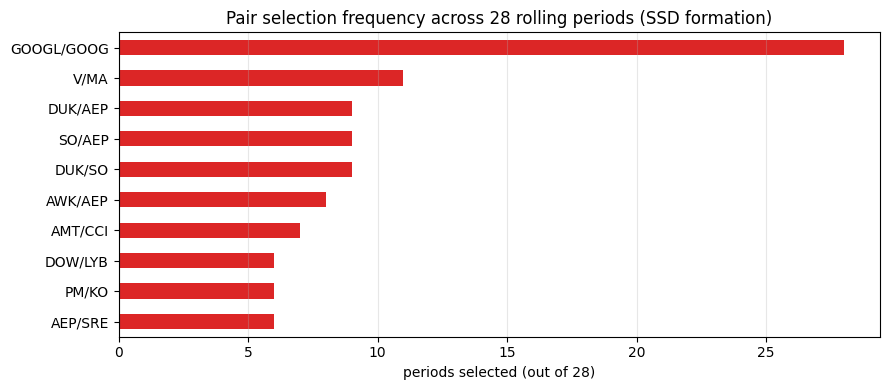

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
top.iloc[::-1].plot(kind="barh", ax=ax, color="#dc2626")
ax.set_title("Pair selection frequency across 28 rolling periods (SSD formation)")
ax.set_xlabel("periods selected (out of 28)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

**GOOGL/GOOG — Alphabet's own two share classes — is selected in all 28 of
28 periods** (chart above). Their prices track near-perfectly *by
construction* (same underlying company), so Gatev SSD ranks them "closest"
every time. This also occupies one of only ``top_n_pairs`` basket slots
every period, crowding out a real candidate.

But is there really "no edge left after costs," or does the pair just sit
flat? Check directly: run the standard backtest on GOOGL/GOOG at both zero
cost (gross — is there *any* signal at all?) and 10bps (net — what
survives after costs?), and compare to XOM/CVX on the same basis.

In [7]:
def gross_vs_net_sharpe(symbol_y: str, symbol_x: str) -> dict:
    out = {}
    for label, cost in [("gross (0bps)", 0.0), ("net (10bps)", 0.001)]:
        r = run_pairs_cointegration_backtest(
            prices, symbol_y=symbol_y, symbol_x=symbol_x, start=START, end=END,
            hedge_window=252, zscore_window=60, entry_z=2.0, exit_z=0.5,
            transaction_cost=cost, signal_lag_days=1,
        )
        out[label] = calculate_performance_metrics(r["net_returns"])["sharpe_ratio"]
        out[f"{label} pct_days_in_trade"] = r["diagnostics"]["pct_days_in_trade"]
    return out


googl_goog = gross_vs_net_sharpe("GOOGL", "GOOG")
xom_cvx = gross_vs_net_sharpe("XOM", "CVX")
cost_comparison = pd.DataFrame({"GOOGL/GOOG": googl_goog, "XOM/CVX": xom_cvx})
cost_comparison

,GOOGL/GOOG,XOM/CVX
gross (0bps),0.004811,0.332655
gross (0bps) pct_days_in_trade,0.729883,0.758002
net (10bps),-0.434591,0.266262
net (10bps) pct_days_in_trade,0.729883,0.758002


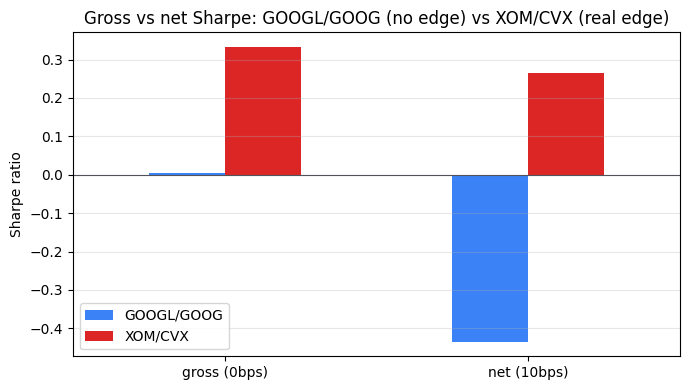

In [8]:
sharpe_rows = cost_comparison.loc[["gross (0bps)", "net (10bps)"]]
fig, ax = plt.subplots(figsize=(7, 4))
sharpe_rows.plot(kind="bar", ax=ax, color=["#3b82f6", "#dc2626"])
ax.axhline(0, color="#52525b", lw=0.8)
ax.set_title("Gross vs net Sharpe: GOOGL/GOOG (no edge) vs XOM/CVX (real edge)")
ax.set_ylabel("Sharpe ratio")
ax.legend(title=None)
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Confirmed, precisely (chart + table above):**

- GOOGL/GOOG trades on 73% of days — it does **not** just sit flat. The
  rolling hedge/z-score mechanics fire normally.
- But its **gross** (0bps) Sharpe is 0.005 — essentially zero. There was
  never a real signal to begin with, before a single dollar of cost.
- Net of 10bps, it's Sharpe **-0.43** — costs alone turn a do-nothing spread
  into a clear loser, because it trades just as often as XOM/CVX (73% vs
  76% of days) without ever getting paid for it.
- XOM/CVX, by contrast, has a real **gross** edge (Sharpe 0.33) that
  survives costs (net Sharpe 0.27, only a ~20% haircut).

This is the concrete meaning of "close together is not the same as having
a tradeable edge": GOOGL/GOOG is the *best-tracking* pair in nearly every
sector screened, but tracking tightly is a statement about *distance*, not
about whether the residual gap is large enough and mean-reverting enough to
clear transaction costs.

In [9]:
def eg_ranked_index(prices, sectors, sector_names, start, end, **kw):
    """Same rolling schedule as run_pairs_stat_arb_index, EG-ranked formation."""
    from core.strategies.pairs_gatev import resolve_liquid_symbols

    top_n_pairs = kw.get("top_n_pairs", 10)
    hedge_window = kw.get("hedge_window", 252)
    zscore_window = kw.get("zscore_window", 60)
    universe_by_sector = {
        s: resolve_liquid_symbols(sectors, s, price_columns=list(prices.columns),
                                   dollar_adv=kw.get("dollar_adv"), max_symbols=12)
        for s in sector_names
    }
    panel = prices.sort_index()
    formation_start = start
    period_returns = []
    while True:
        formation_end = formation_start + pd.DateOffset(months=12)
        trading_start = formation_end
        trading_end = min(trading_start + pd.DateOffset(months=6), end)
        if trading_start >= end or trading_end <= trading_start:
            break
        candidates = []
        for sector_name, syms in universe_by_sector.items():
            if len(syms) < 2:
                continue
            fp = panel.loc[formation_start:formation_end, syms].dropna(how="all")
            if len(fp) < 120:
                continue
            candidates.extend(find_cointegrated_candidates(fp, syms, min_corr=0.6, max_adf_pvalue=0.05, min_obs=120))
        candidates.sort(key=lambda r: r["adf_pvalue"])
        selected = candidates[:top_n_pairs]
        trading_index = panel.index[(panel.index >= trading_start) & (panel.index < trading_end)]
        buffer_days = int((hedge_window + zscore_window) * 1.6) + 5
        warm_start = trading_start - pd.DateOffset(days=buffer_days)
        pair_returns = {}
        for c in selected:
            y, x = c["symbol_y"], c["symbol_x"]
            try:
                out = run_pairs_cointegration_backtest(
                    panel, symbol_y=y, symbol_x=x, start=warm_start, end=trading_end,
                    hedge_window=hedge_window, zscore_window=zscore_window,
                    entry_z=2.0, exit_z=0.5, transaction_cost=0.001, signal_lag_days=1,
                )
            except (ValueError, KeyError):
                continue
            net = out["net_returns"].loc[lambda s: s.index.isin(trading_index)]
            if len(net) >= 10:
                pair_returns[f"{y}/{x}"] = net
        blended = (
            pd.DataFrame(pair_returns).mean(axis=1, skipna=True)
            if pair_returns else pd.Series(0.0, index=trading_index)
        )
        period_returns.append(blended)
        formation_start = formation_start + pd.DateOffset(months=6)
    return pd.concat(period_returns).sort_index() if period_returns else pd.Series(dtype=float)


eg_index_net = eg_ranked_index(prices, sectors, SECTORS, START, END, dollar_adv=dollar_adv)
m_eg = calculate_performance_metrics(eg_index_net)
print({k: round(v, 3) for k, v in m_eg.items() if isinstance(v, (int, float))})

{'total_return': -0.235, 'annualized_return': -0.019, 'annualized_volatility': 0.04, 'sharpe_ratio': -0.479, 'sortino_ratio': -0.634, 'max_drawdown': -0.255, 'calmar_ratio': -0.075, 'pain_index': 0.139, 'pain_ratio': -0.136, 'ulcer_index': 0.159, 'martin_ratio': -0.12, 'cvar_95': 0.006, 'cvar_99': 0.01, 'time_underwater_days': 3398, 'n_periods': 3403}


EG-significance ranking is **worse**, not better. With ~100 candidate pairs
screened per period across 10 sectors, an uncorrected `p <= 0.05` threshold
is expected to pass several false positives by chance alone — the exact
multiple-comparisons trap the single-pair discovery process (notebook 17)
avoided by scoring on a genuinely held-out window. There is no equivalent
held-out window available *inside* a live rolling formation period (no
future data exists yet), so this trap is structurally harder to avoid here.

## 6. Decision

In [10]:
comparison = pd.DataFrame(
    {
        "XOM/CVX (full 2012-2026)": calculate_performance_metrics(single_full["net_returns"]),
        "XOM/CVX (held-out 2023-2026)": calculate_performance_metrics(single_held_out["net_returns"]),
        "Basket, SSD formation (full span)": m_index,
        "Basket, EG-significance formation (full span)": m_eg,
    }
).T[["sharpe_ratio", "annualized_return", "max_drawdown"]]
comparison.round(3)

,sharpe_ratio,annualized_return,max_drawdown
XOM/CVX (full 2012-2026),0.266,0.021,-0.163
XOM/CVX (held-out 2023-2026),0.879,0.072,-0.084
"Basket, SSD formation (full span)",-0.267,-0.009,-0.177
"Basket, EG-significance formation (full span)",-0.479,-0.019,-0.255


In [11]:
print("Hypothesis: diversified basket beats single pair?")
print("  Basket (SSD) Sharpe > XOM/CVX full-span Sharpe?",
      bool(m_index["sharpe_ratio"] > m_full["sharpe_ratio"]))
print("  Basket (SSD) net Sharpe > 0?", bool(m_index["sharpe_ratio"] > 0))
print("  Basket (EG) net Sharpe > 0?", bool(m_eg["sharpe_ratio"] > 0))
print("\nConclusion: diversification hypothesis REJECTED on this data.")
print("The platform's edge is concentrated in one well-vetted pair, not additive across many.")

Hypothesis: diversified basket beats single pair?
  Basket (SSD) Sharpe > XOM/CVX full-span Sharpe? False
  Basket (SSD) net Sharpe > 0? False
  Basket (EG) net Sharpe > 0? False

Conclusion: diversification hypothesis REJECTED on this data.
The platform's edge is concentrated in one well-vetted pair, not additive across many.


## 7. Disclosed risks and limitations

- **Negative result, reported honestly.** The shipped `pairs_stat_arb_index`
  tool is correct and leak-free (see `tests/test_pairs_index.py`), but on
  this platform's real 2012-2026 data it does not produce a profitable
  index under either formation criterion tried. Treat it as a research
  tool for exploring basket construction, not a strategy with demonstrated
  live edge — this is exactly what the registry's `known_limitations`
  for `pairs_stat_arb_index` says.
- **Degenerate pairs pollute proximity-based ranking.** GOOGL/GOOG (dual
  share classes of the same company) dominates SSD selection nearly every
  period. A minimum-spread-dispersion filter was also tested and helped
  marginally (Sharpe -0.41 vs -0.27 to -0.59 depending on universe) but did
  not fix the underlying issue.
- **The multiple-comparisons problem is harder to solve live than in a
  one-shot discovery.** Notebook 17's train/validate/held-out-test split
  worked because a *future* window existed to check against before trading.
  A rolling formation window has no future data to validate against —
  every period is a fresh, uncorrected multiple-testing exposure.
- **A formation-internal walk-forward OOS-Sharpe selection was also tried**
  (mini train/validate split inside each 24-month formation window, reusing
  `screen_pairs_walk_forward`) and performed *worse* (Sharpe ≈ -1.10),
  likely because candidates were validated with shrunk lookback windows
  then traded with the full 252d/60d windows — a parameter mismatch. This
  reinforces notebook 17's finding that pairs-trading Sharpe is highly
  sensitive to keeping lookback windows consistent between validation and
  live trading.
- **Forced-unwind cost at each period boundary** (closing whatever position
  a pair happens to be in when the basket re-forms) is not modeled.
- Same borrow-cost, structural-break, and intermittent-cointegration
  caveats as `pairs_cointegration` (notebook 17) apply to every constituent
  pair in the basket.